# REI-TuRBO Benchmark Test

In [1]:
# Import necessary libraries
import warnings, os, torch, copy,sys

os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


try:
    from optimpv import *
    from optimpv import FitParam
    from optimpv.tests.HPA import HPAAgent, HPAModel
    from optimpv.optimizers.axBOtorch.axBOtorchOptimizer import axBOtorchOptimizer
except Exception as e:
    sys.path.append('../') # add the path to the optimpv module
    from optimpv import *
    from optimpv import FitParam
    from optimpv.tests.HPA import HPAAgent, HPAModel
    from optimpv.optimizers.axBOtorch.axBOtorchOptimizer import axBOtorchOptimizer

plt.style.use('default')

## Benchmark Setup

Information about the HPA(human-powered aircraft) can be found here: https://github.com/Nobuo-Namura/hpa

In [2]:
# Main notebook setup
# change these parameters to run different problems with varying number of dimensions -> n_div and level
problem_name = 'HPA101' # HPA101, HPA102, HPA103
n_div = 4
level = 0
normalized = True

total_evaluations = 160
n_init = 20
batch_size = 2
seed = np.random.randint(0, 10000) 

# add the variations, list of name, method -> reiturbo or turbo, acquisition function -> ts or ei, and number of trust regions for reiturbo
variations = [
    {'label': 'TuRBO-1 - TS', 'method': 'turbo', 'acq': 'ts'},
    {'label': 'TuRBO-1 - EI', 'method': 'turbo', 'acq': 'ei'},
    {'label': 'REI-TuRBO-1 - TS', 'method': 'reiturbo', 'acq': 'ts', 'n_trust_regions': 1},
    {'label': 'REI-TuRBO-1 - EI', 'method': 'reiturbo', 'acq': 'ei', 'n_trust_regions': 1},
    {'label': 'REI-TuRBO-2 - EI', 'method': 'reiturbo', 'acq': 'ei', 'n_trust_regions': 2},
    {'label': 'REI-TuRBO-4 - EI', 'method': 'reiturbo', 'acq': 'ei', 'n_trust_regions': 4},
]

print(f'Problem: {problem_name}-{level}')
print(f'Total evaluations per variation: {total_evaluations * batch_size}')
print(f'Seed: {seed}')
print('variations:')
for variation in variations:
    print('  -', variation['label'])

Problem: HPA101-0
Total evaluations per variation: 320
Seed: 4051
variations:
  - TuRBO-1 - TS
  - TuRBO-1 - EI
  - REI-TuRBO-1 - TS
  - REI-TuRBO-1 - EI
  - REI-TuRBO-2 - EI
  - REI-TuRBO-4 - EI


In [3]:
# Build the HPA benchmark model and define the optimization parameters
hpa_model = HPAModel(
    problem_name=problem_name,
    n_div=n_div,
    level=level,
    normalized=normalized,
)

params = []
for i in range(hpa_model.nx):
    params.append(
        FitParam(
            name=f'x{i}',
            value=0.5,
            bounds=[0.0, 1.0],
            value_type='float',
            type='range',
            display_name=f'x{i}',
            axis_type='linear',
        )
    )

print(f'Dimension: {hpa_model.nx}D')
print(f'Number of objectives: {hpa_model.nf}')
print(f'Number of explicit constraints: {hpa_model.ng}')
print(f'Initial midpoint objective: {hpa_model.evaluate(np.full(hpa_model.nx, 0.5))[0][0]:.6f}')

Dimension: 17D
Number of objectives: 1
Number of explicit constraints: 0
Initial midpoint objective: 26.070936


In [4]:
# Define the Agent and the target metric/loss function
hpa_agent = HPAAgent(
    params=params,
    problem_name=problem_name,
    n_div=n_div,
    level=level,
    normalized=normalized,
    metric='obj',
    loss='linear',
    minimize=True,
    name='hpa101',
)

print('Agent metric name:', hpa_agent.all_agent_metrics)

Agent metric name: ['hpa101_HPA101_obj_linear']


In [5]:
import time

#put the optimizer building into functions along with the history data extraction

def build_optimizer(variation, seed=0):
    params_local = copy.deepcopy(params)
    agent_local = HPAAgent(
        params=params_local,
        problem_name=problem_name,
        n_div=n_div,
        level=level,
        normalized=normalized,
        metric='obj',
        loss='linear',
        minimize=True,
        name='hpa101',
    )

    if variation['method'] == 'turbo':
        model_kwargs_list = [
            {},
            {
                'torch_device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
                'torch_dtype': torch.double,
                'acq': variation['acq'],
                'seed': seed,
            },
        ]
        models = ['SOBOL', 'TURBO']
    elif variation['method'] == 'reiturbo':
        model_kwargs_list = [
            {},
            {
                'torch_device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
                'torch_dtype': torch.double,
                'acq': variation['acq'],
                'n_trust_regions': variation['n_trust_regions'],
                'region_init_points': 4,
                'racqf': 'REI',
                'seed': seed,
            },
        ]
        models = ['SOBOL', 'REITURBO']
    else:
        raise ValueError(f"Unknown method: {variation['method']}")

    return axBOtorchOptimizer(
        params=params_local,
        agents=agent_local,
        models=models,
        n_batches=[1, total_evaluations - n_init],
        batch_size=[n_init, batch_size],
        model_kwargs_list=model_kwargs_list,
        max_parallelism=1,
        verbose_logging=True,
    )


def extract_history(optimizer):
    df = optimizer.ax_client._experiment.lookup_data().df.copy()
    metric_name = df['metric_name'].iloc[0]
    hist = (
        df[df['metric_name'] == metric_name]
        .sort_values('trial_index')
        .loc[:, ['trial_index', 'mean']]
        .reset_index(drop=True)
    )
    hist['evaluation'] = np.arange(1, len(hist) + 1)
    hist['best_obj_val'] = hist['mean'].cummin()
    return hist, metric_name

def run_variation(variation, seed=0):
    optimizer = build_optimizer(variation=variation, seed=seed)
    start_time = time.time()
    optimizer.optimize()
    end_time = time.time() - start_time
    history, metric_name = extract_history(optimizer)
    return {
        'label': variation['label'],
        'history': history,
        'metric_name': metric_name,
        'runtime': end_time,
        'best_value': float(history['best_obj_val'].iloc[-1]),
    }

## Run All Six Variations

In [6]:
runs = []
for variation in variations:
    print(f"Running {variation['label']}") # set verbose logging = False to see just the prints
    runs.append(run_variation(variation, seed=seed))

Running TuRBO-1 - TS


[INFO 03-30 18:04:14] optimpv.axBOtorchOptimizer: Trial 0 with parameters: {'x0': 0.7811523731797934, 'x1': 0.014826356433331966, 'x2': 0.17315888032317162, 'x3': 0.5108178295195103, 'x4': 0.5527735585346818, 'x5': 0.8122863424941897, 'x6': 0.2671758197247982, 'x7': 0.8966872775927186, 'x8': 0.20384684577584267, 'x9': 0.5596964554861188, 'x10': 0.527193596586585, 'x11': 0.7449324866756797, 'x12': 0.8869095277041197, 'x13': 0.19932478573173285, 'x14': 0.32570322044193745, 'x15': 0.4508204786106944, 'x16': 0.8028093483299017}
[INFO 03-30 18:04:14] optimpv.axBOtorchOptimizer: Trial 1 with parameters: {'x0': 0.3922828696668148, 'x1': 0.8032156238332391, 'x2': 0.5313421692699194, 'x3': 0.2685370510444045, 'x4': 0.2277610432356596, 'x5': 0.4944485891610384, 'x6': 0.6122391857206821, 'x7': 0.3064708365127444, 'x8': 0.6198965096846223, 'x9': 0.11619417183101177, 'x10': 0.24902185052633286, 'x11': 0.09084643330425024, 'x12': 0.39310976304113865, 'x13': 0.8755782982334495, 'x14': 0.7501348899677

Running TuRBO-1 - EI


[INFO 03-30 18:05:01] optimpv.axBOtorchOptimizer: Trial 0 completed with results: {'hpa101_HPA101_obj_linear': 26.333188637736598}
[INFO 03-30 18:05:01] optimpv.axBOtorchOptimizer: Trial 1 completed with results: {'hpa101_HPA101_obj_linear': 82.5546434889603}
[INFO 03-30 18:05:01] optimpv.axBOtorchOptimizer: Trial 2 completed with results: {'hpa101_HPA101_obj_linear': 38.72266588327667}
[INFO 03-30 18:05:01] optimpv.axBOtorchOptimizer: Trial 3 completed with results: {'hpa101_HPA101_obj_linear': 46.49297700866671}
[INFO 03-30 18:05:01] optimpv.axBOtorchOptimizer: Trial 4 completed with results: {'hpa101_HPA101_obj_linear': 77.39729510303474}
[INFO 03-30 18:05:01] optimpv.axBOtorchOptimizer: Trial 5 completed with results: {'hpa101_HPA101_obj_linear': 25.55936142460724}
[INFO 03-30 18:05:01] optimpv.axBOtorchOptimizer: Trial 6 completed with results: {'hpa101_HPA101_obj_linear': 26.463894012226234}
[INFO 03-30 18:05:01] optimpv.axBOtorchOptimizer: Trial 7 completed with results: {'hpa10

Running REI-TuRBO-1 - TS


...

[INFO 03-30 18:07:27] optimpv.axBOtorchOptimizer: Trial 0 completed with results: {'hpa101_HPA101_obj_linear': 32.14373264687187}
[INFO 03-30 18:07:27] optimpv.axBOtorchOptimizer: Trial 1 completed with results: {'hpa101_HPA101_obj_linear': 35.36713386097018}
[INFO 03-30 18:07:27] optimpv.axBOtorchOptimizer: Trial 2 completed with results: {'hpa101_HPA101_obj_linear': 30.055051250481334}
[INFO 03-30 18:07:27] optimpv.axBOtorchOptimizer: Trial 3 completed with results: {'hpa101_HPA101_obj_linear': 45.82373771083661}
[INFO 03-30 18:07:27] optimpv.axBOtorchOptimizer: Trial 4 completed with results: {'hpa101_HPA101_obj_linear': 29.69681336604654}
[INFO 03-30 18:07:27] optimpv.axBOtorchOptimizer: Trial 5 completed with results: {'hpa101_HPA101_obj_linear': 63.02646812298861}
[INFO 03-30 18:07:27] optimpv.axBOtorchOptimizer: Trial 6 completed with results: {'hpa101_HPA101_obj_linear': 55.0655967818622}
[INFO 03-30 18:07:27] optimpv.axBOtorchOptimizer: Trial 7 completed with results: {'hpa101

Running REI-TuRBO-2 - EI


[INFO 03-30 18:10:06] optimpv.axBOtorchOptimizer: Trial 0 completed with results: {'hpa101_HPA101_obj_linear': 30.536721814502247}
[INFO 03-30 18:10:06] optimpv.axBOtorchOptimizer: Trial 1 completed with results: {'hpa101_HPA101_obj_linear': 28.419490911534325}
[INFO 03-30 18:10:06] optimpv.axBOtorchOptimizer: Trial 2 completed with results: {'hpa101_HPA101_obj_linear': 49.81080107780585}
[INFO 03-30 18:10:06] optimpv.axBOtorchOptimizer: Trial 3 completed with results: {'hpa101_HPA101_obj_linear': 69.706776964266}
[INFO 03-30 18:10:06] optimpv.axBOtorchOptimizer: Trial 4 completed with results: {'hpa101_HPA101_obj_linear': 60.22158902667388}
[INFO 03-30 18:10:06] optimpv.axBOtorchOptimizer: Trial 5 completed with results: {'hpa101_HPA101_obj_linear': 30.04598392139256}
[INFO 03-30 18:10:06] optimpv.axBOtorchOptimizer: Trial 6 completed with results: {'hpa101_HPA101_obj_linear': 48.16317326796204}
[INFO 03-30 18:10:06] optimpv.axBOtorchOptimizer: Trial 7 completed with results: {'hpa101

Running REI-TuRBO-4 - EI


[INFO 03-30 18:12:36] optimpv.axBOtorchOptimizer: Trial 0 completed with results: {'hpa101_HPA101_obj_linear': 40.390664736541574}
[INFO 03-30 18:12:36] optimpv.axBOtorchOptimizer: Trial 1 completed with results: {'hpa101_HPA101_obj_linear': 63.326797130542815}
[INFO 03-30 18:12:36] optimpv.axBOtorchOptimizer: Trial 2 completed with results: {'hpa101_HPA101_obj_linear': 29.717844512610093}
[INFO 03-30 18:12:36] optimpv.axBOtorchOptimizer: Trial 3 completed with results: {'hpa101_HPA101_obj_linear': 30.86773572279052}
[INFO 03-30 18:12:36] optimpv.axBOtorchOptimizer: Trial 4 completed with results: {'hpa101_HPA101_obj_linear': 28.207549121015603}
[INFO 03-30 18:12:36] optimpv.axBOtorchOptimizer: Trial 5 completed with results: {'hpa101_HPA101_obj_linear': 33.46253806174019}
[INFO 03-30 18:12:36] optimpv.axBOtorchOptimizer: Trial 6 completed with results: {'hpa101_HPA101_obj_linear': 70.32308406692025}
[INFO 03-30 18:12:36] optimpv.axBOtorchOptimizer: Trial 7 completed with results: {'hp

In [7]:
summary_df = pd.DataFrame(
    {
        'variation': run['label'],
        'runtime': run['runtime'],
        'best_value': run['best_value'],
    }
    for run in runs
).sort_values('best_value').reset_index(drop=True)

summary_df

,variation,runtime,best_value
0,REI-TuRBO-4 - EI,390.414352,22.572660
1,REI-TuRBO-2 - EI,149.652322,22.708119
2,REI-TuRBO-1 - TS,50.934398,22.711603
3,TuRBO-1 - TS,46.382188,22.831078
4,REI-TuRBO-1 - EI,158.442324,22.844398
5,TuRBO-1 - EI,95.403118,23.112230


## Comparison Plot

Best-so-far objective values of each variation.

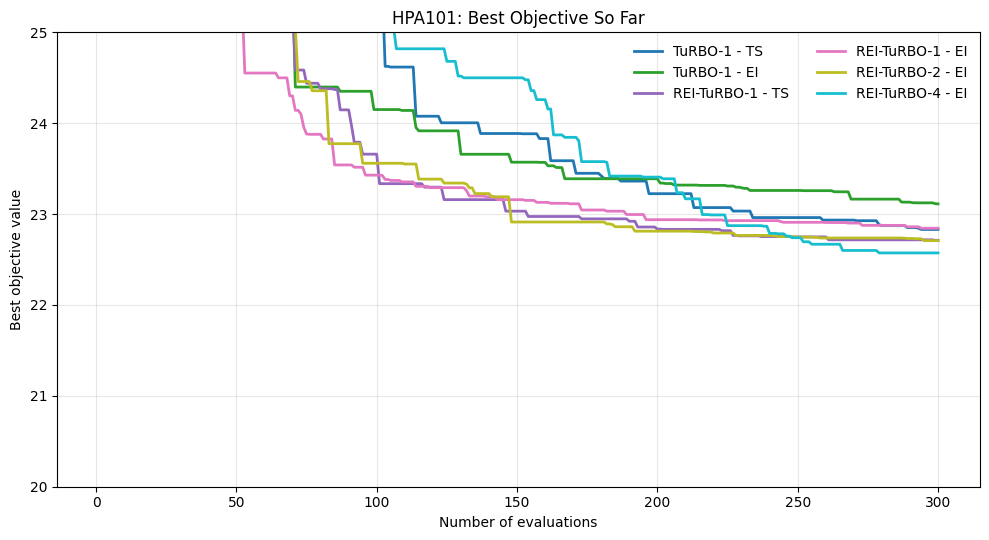

In [8]:
colors = plt.get_cmap('tab10')(np.linspace(0, 1, len(runs)))

fig, ax = plt.subplots(figsize=(10, 5.5))

for color, run in zip(colors, runs):
    hist = run['history']
    ax.plot(
        hist['evaluation'],
        hist['best_obj_val'],
        color=color,
        lw=2.0,
        label=run['label'],
    )

ax.set_title('HPA101: Best Objective So Far')
ax.set_xlabel('Number of evaluations')
ax.set_ylabel('Best objective value')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', frameon=False, ncol=2)
ax.set_ylim(20, 25)
plt.tight_layout()
plt.show()
